# Car Price Prediction with Machine Learning

**OIBSIP Data Science — Task 3**


## Dataset and objective

This project predicts used-car selling prices from vehicle characteristics using the Cardekho dataset.


Original shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
Cleaned shape: (299, 11)
Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Car_Age          0
Brand            0
dtype: int64
Brands: 44


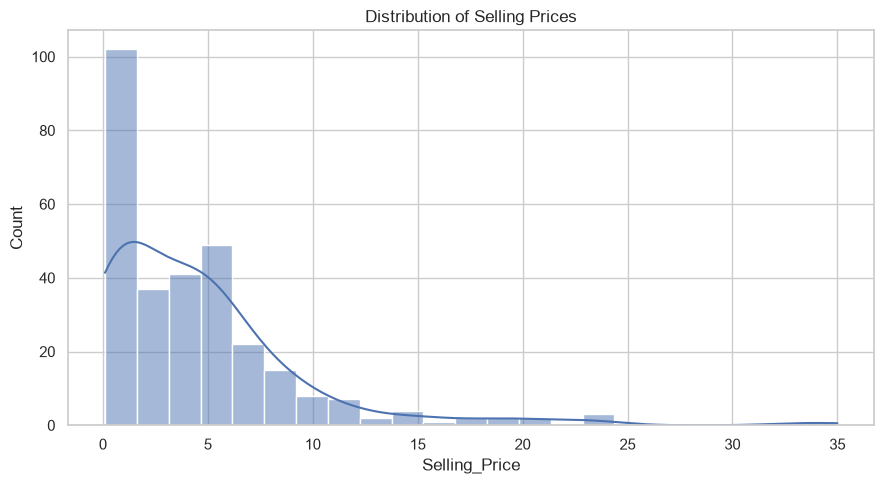

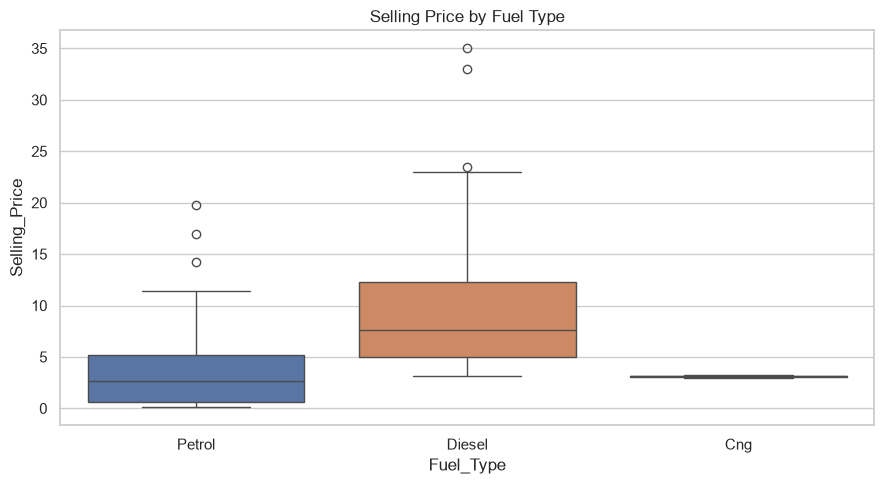

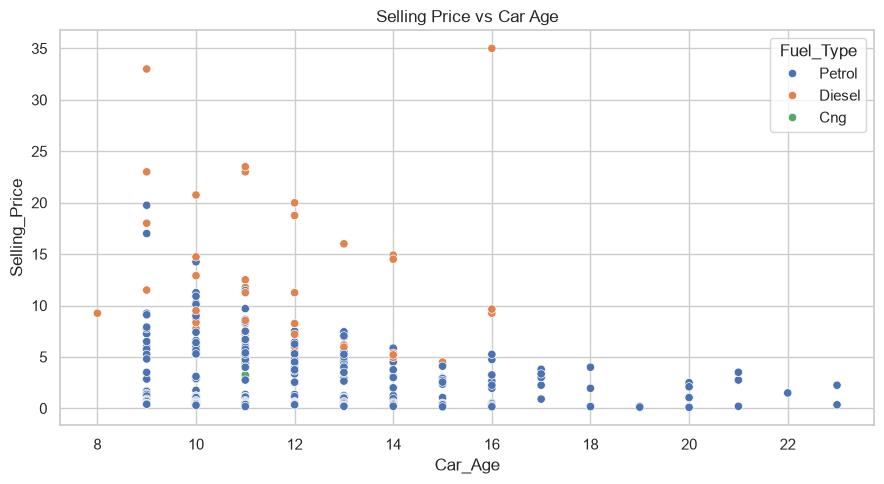

C:\Users\abina g a\AppData\Local\Temp\ipykernel_20008\3839144858.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=X.select_dtypes(include="object").columns.tolist(); num=X.select_dtypes(exclude="object").columns.tolist()


Model evaluation:
                      Model    MAE   RMSE     R2
0        Linear Regression  1.348  2.389  0.779
1  Random Forest Regressor  1.424  3.503  0.524
Best model: Linear Regression


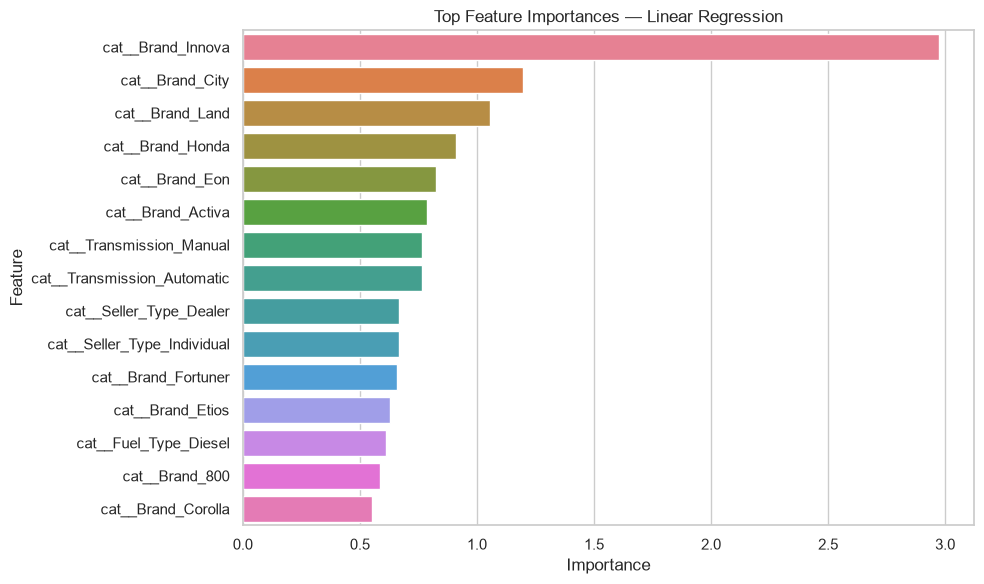

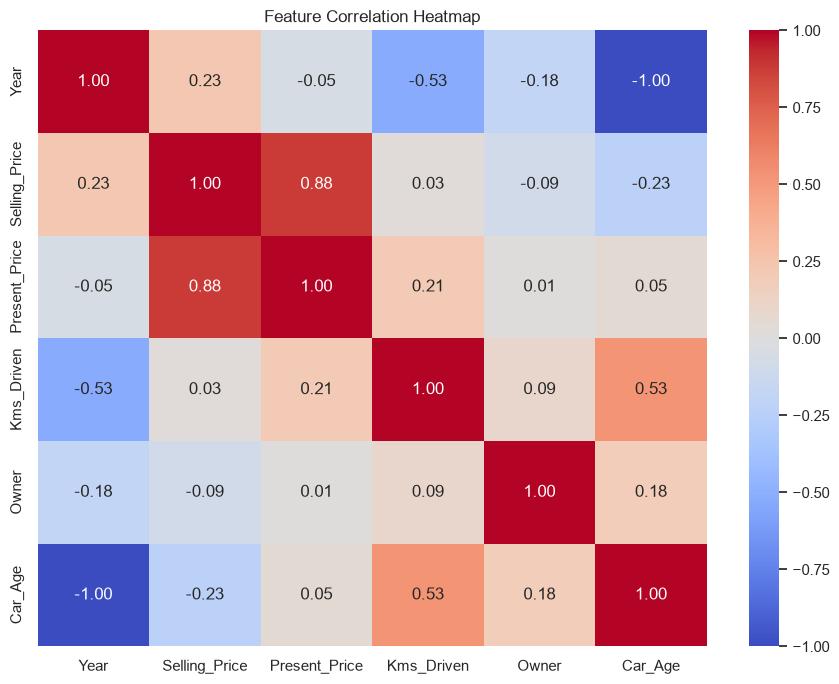

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid"); OUT=Path("outputs"); OUT.mkdir(exist_ok=True)
df=pd.read_csv("car data.csv"); print("Original shape:",df.shape); print(df.head())
# Cleaning and consistent categorical values
df.columns=df.columns.str.strip(); df=df.drop_duplicates().dropna().copy()
for c in ["Fuel_Type","Seller_Type","Transmission"]: df[c]=df[c].astype(str).str.strip().str.title()
# Feature engineering: car age and brand
df["Car_Age"]=pd.Timestamp.now().year-df["Year"]
df["Brand"]=df["Car_Name"].str.split().str[0].str.title()
print("Cleaned shape:",df.shape); print("Missing values:\n",df.isna().sum()); print("Brands:",df.Brand.nunique())
# EDA
plt.figure(figsize=(9,5)); sns.histplot(df["Selling_Price"],kde=True); plt.title("Distribution of Selling Prices"); plt.tight_layout(); plt.savefig(OUT/"selling_price_distribution.png",dpi=180); plt.show()
plt.figure(figsize=(9,5)); sns.boxplot(data=df,x="Fuel_Type",y="Selling_Price",hue="Fuel_Type",legend=False); plt.title("Selling Price by Fuel Type"); plt.tight_layout(); plt.savefig(OUT/"price_by_fuel.png",dpi=180); plt.show()
plt.figure(figsize=(9,5)); sns.scatterplot(data=df,x="Car_Age",y="Selling_Price",hue="Fuel_Type"); plt.title("Selling Price vs Car Age"); plt.tight_layout(); plt.savefig(OUT/"price_vs_age.png",dpi=180); plt.show()
# Encode categories and split
X=df.drop(columns=["Selling_Price","Car_Name"]); y=df["Selling_Price"]
cat=X.select_dtypes(include="object").columns.tolist(); num=X.select_dtypes(exclude="object").columns.tolist()
pre=ColumnTransformer([("cat",OneHotEncoder(handle_unknown="ignore"),cat),("num","passthrough",num)])
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=42)
models={"Linear Regression":LinearRegression(),"Random Forest Regressor":RandomForestRegressor(n_estimators=300,random_state=42)}; results=[]; fitted={}
for name,m in models.items():
 pipe=Pipeline([("preprocessor",pre),("model",m)]); pipe.fit(Xtr,ytr); pred=pipe.predict(Xte); fitted[name]=pipe
 results.append({"Model":name,"MAE":mean_absolute_error(yte,pred),"RMSE":np.sqrt(mean_squared_error(yte,pred)),"R2":r2_score(yte,pred)})
results=pd.DataFrame(results).sort_values("R2",ascending=False); print("Model evaluation:\n",results.round(3)); results.to_csv(OUT/"model_evaluation.csv",index=False)
best=results.iloc[0]["Model"]; print("Best model:",best)
# Feature importance for the selected best model
pipe=fitted[best]; names=pipe.named_steps["preprocessor"].get_feature_names_out(); model=pipe.named_steps["model"]
imp=model.feature_importances_ if hasattr(model,"feature_importances_") else np.abs(model.coef_)
fi=pd.DataFrame({"Feature":names,"Importance":np.ravel(imp)}).sort_values("Importance",ascending=False).head(15); fi.to_csv(OUT/"feature_importance.csv",index=False); plt.figure(figsize=(10,6)); sns.barplot(data=fi,x="Importance",y="Feature",hue="Feature",legend=False); plt.title(f"Top Feature Importances — {best}"); plt.tight_layout(); plt.savefig(OUT/"feature_importance.png",dpi=180); plt.show()
# correlation heatmap of numeric variables
plt.figure(figsize=(9,7)); sns.heatmap(df.select_dtypes(exclude="object").corr(),annot=True,fmt=".2f",cmap="coolwarm"); plt.title("Feature Correlation Heatmap"); plt.tight_layout(); plt.savefig(OUT/"correlation_heatmap.png",dpi=180); plt.show()
df.to_csv(OUT/"cleaned_car_data.csv",index=False)


## Cleaning and feature engineering

Nulls and duplicates are handled; categorical values are standardized. Car age is calculated from year and brand is extracted from car name.


## Exploratory data analysis

The notebook examines selling-price distribution, price by fuel type, price by car age, and feature correlations.


## Modeling and evaluation

Categorical variables are one-hot encoded. Linear Regression and Random Forest Regressor are evaluated with MAE, RMSE, and R².


## Conclusion

The model with the highest R² is selected as best, and its feature importances are visualized. Results are descriptive and depend on the dataset and split.
